# Baixando datast do Kaggle
> Bixando dataset cats and dogs

> O kaggle da o comando no site


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


## Analisando nosso dataset

In [2]:
import os

data_dir = os.path.join(path, "PetImages")

dog_path = os.path.join(data_dir, 'Dog')
cat_path = os.path.join(data_dir, 'Cat')

dog_imgs = os.listdir(dog_path)
cat_imgs = os.listdir(cat_path)

print(f"Cat images: {len(dog_imgs)}")
print(f"Dog images: {len(cat_imgs)}")
print(f"Total images: {len(dog_imgs) + len(cat_imgs)}")

print(f"First 5 cat images: {cat_imgs[:5]}")
print(f"First 5 dog images: {dog_imgs[:5]}")

dog_imgs = [os.path.join(dog_path, img) for img in dog_imgs]
cat_imgs = [os.path.join(cat_path, img) for img in cat_imgs]

print(f"First cat image: {cat_imgs[0]}")
print(f"First dog image: {dog_imgs[0]}")

Cat images: 12499
Dog images: 12499
Total images: 24998
First 5 cat images: ['7981.jpg', '6234.jpg', '1269.jpg', '3863.jpg', '6241.jpg']
First 5 dog images: ['7981.jpg', '6234.jpg', '1269.jpg', '3863.jpg', '6241.jpg']
First cat image: /kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat/7981.jpg
First dog image: /kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog/7981.jpg


## Separando dataset

In [27]:
import tensorflow as tf
from tensorflow import keras

train_ds, tmp_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    image_size=(128,128),
    seed=123,
    subset="both",
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)



Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Using 4999 files for validation.
['Cat', 'Dog']


In [28]:
val_ds = tmp_ds.take(100)
test_ds = tmp_ds.skip(100)

train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
tmp_ds = tmp_ds.apply(tf.data.experimental.ignore_errors())

# Versões reduzidas
train_ds_fast = train_ds.take(300)
val_ds_fast = val_ds.take(60)
test_ds_fast = test_ds.take(30)

## Criando o nosso modelo de Rede Neural Convolucional (CNN)

In [7]:
from keras import models, layers

model = models.Sequential([
  # Antes
  # layers.Flatten(input_shape=(28,28)) # Camada de achatametno
  # layers.Dense(512, activation=tensorflow.nn.relu), # camadas da RNA

  # Agora
  # layers.Input(shape=(img_height, img_width, 3)), # falando para rede o tamanho do input
  # layers.Rescaling(1/255.0), # rescale dos pixels
  # layers.Conv2D(32, (3, 3), activation='relu', padding='same'), # varre a imagem procurando 32 padrões diferentes
  # layers.MaxPooling2D((2, 2)), # reduz a imagem pela metade guardando só o que importa
  # layers.BatchNormalization(), # mantém os números equilibrados para a IA aprender mais rápido
  # layers.Dropout(0.25), #  desliga os neurônios aleatoriamente para evitar overfitting

  layers.Input(shape=(128,128,3)),

  layers.Rescaling(1./255),

  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Dropout(0.5),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Dropout(0.5),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Dropout(0.5),

  layers.Flatten(),

  layers.Dense(128, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.2),

  layers.Dense(2, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,082 (8.10 MB)

 Trainable params: 2,121,602 (8.09 MB)

 Non-trainable params: 480 (1.88 KB)

## Compilando e treinando o modelo

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


train_stats = model.fit(
  train_ds_fast,
  validation_data=val_ds_fast,
  epochs=1,
  batch_size=32
)

In [ ]:
print(f"Loss final de Treino: {train_stats.history['loss'][-1]}")
print(f"Acurácia final de Treino: {train_stats.history['accuracy'][-1]}")

print(f"Loss final de Validação: {train_stats.history['val_loss'][-1]}")
print(f"Acurácia final de Validação: {train_stats.history['val_accuracy'][-1]}")

test_loss, test_accuracy = model.evaluate(test_ds_fast)

print(f"Loss de teste foi : {test_loss}")
print(f"Acurácia de teste foi : {test_accuracy}")

## Testando com imagens do google

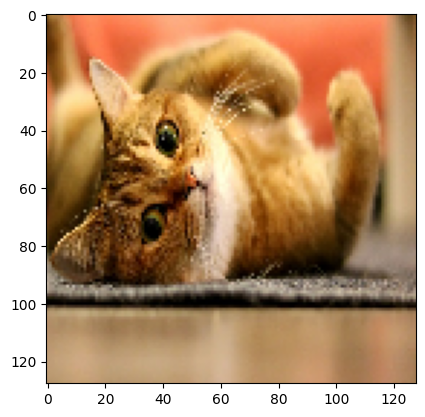

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Resultado da IA: Dog (com 100.00% de confiança!)


In [31]:
import matplotlib.pyplot as plt
import numpy as np

img_url = "https://blog-static.petlove.com.br/wp-content/uploads/2019/06/shutterstock_632318627.jpg"

img_path = tf.keras.utils.get_file(origin=img_url)

img = tf.keras.utils.load_img(
    img_path, target_size=(128, 128)
)

plt.imshow(img)
plt.show()

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
img_array = img_array / 255.0

predictions = model.predict(img_array)

classe_predita = class_names[np.argmax(predictions)]
confianca = 100 * np.max(predictions)

print(f"\nResultado da IA: {classe_predita} (com {confianca:.2f}% de confiança!)")